In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import os

In [95]:
#load the data
#IPCI
pci_df = pd.read_csv("weekly_pci_container_new.csv", parse_dates=["week"])
pci_df = pci_df[["week", "IPCI"]].set_index("week").sort_index()
print(pci_df.head(10))
pci_df.to_csv("week-IPCI.csv")

                IPCI
week                
2019-12-30  4.030125
2020-01-06  5.543432
2020-01-13  2.430611
2020-01-20  2.418202
2020-01-27  2.907034
2020-02-03  3.074843
2020-02-10  7.477957
2020-02-17  1.957432
2020-02-24  3.900709
2020-03-02  2.187603


In [96]:
#TEU
teu_df = pd.read_csv("洛杉矶_纽约到港效率.csv")
teu_df['start_postime'] = pd.to_datetime(teu_df['start_postime'], dayfirst=True).dt.tz_localize(None)
week_start_reference = pd.to_datetime('2019-12-30')
teu_df['week_start'] = week_start_reference + pd.to_timedelta(((teu_df['start_postime'] - week_start_reference).dt.days // 7) * 7, unit='D')
teu_df = teu_df[
    (teu_df["shiptype"] == "集装箱") &
    (teu_df["leg_end_port_code"] == "USNYK")]# save the rows whose type is “集装箱”,port="New York"
teu_df = teu_df.groupby('week_start').agg({
    'teu': 'sum',
    'shiptype': 'first',  
    'leg_end_port_code': 'first'
}).reset_index()
teu_df=teu_df.set_index("week_start").sort_index()
print(teu_df.head(10))
teu_df.to_csv("TEU.csv")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29944\1956815857.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  teu_df['start_postime'] = pd.to_datetime(teu_df['start_postime'], dayfirst=True).dt.tz_localize(None)


                 teu shiptype leg_end_port_code
week_start                                     
2019-12-30  237335.0      集装箱             USNYK
2020-01-06  302534.0      集装箱             USNYK
2020-01-13  212392.0      集装箱             USNYK
2020-01-20  256938.0      集装箱             USNYK
2020-01-27  274264.0      集装箱             USNYK
2020-02-03  260377.0      集装箱             USNYK
2020-02-10  279715.0      集装箱             USNYK
2020-02-17  211202.0      集装箱             USNYK
2020-02-24  270300.0      集装箱             USNYK
2020-03-02  244103.0      集装箱             USNYK


In [97]:
combined_df = pd.merge(pci_df, teu_df, left_index=True, right_index=True, how="inner") #combine
combined_df = combined_df.drop(columns=["shiptype", "leg_end_port_code"])
combined_df = combined_df.iloc[:-18] #Since the last 18rows contain some outliers, so I delete them
print(combined_df.head(10))#combined
combined_df.to_csv("combined_df.csv")

                IPCI       teu
2019-12-30  4.030125  237335.0
2020-01-06  5.543432  302534.0
2020-01-13  2.430611  212392.0
2020-01-20  2.418202  256938.0
2020-01-27  2.907034  274264.0
2020-02-03  3.074843  260377.0
2020-02-10  7.477957  279715.0
2020-02-17  1.957432  211202.0
2020-02-24  3.900709  270300.0
2020-03-02  2.187603  244103.0


In [98]:
#Engle-Granger Test
from statsmodels.tsa.stattools import coint
score, pvalue, _ = coint(combined_df["IPCI"], combined_df["teu"])
print(f"协整检验的 p-value: {pvalue:.4f}")
if pvalue < 0.05:
    print("两者协整：存在长期关系，可以使用 VECM")
else:
    print("不协整：不建议使用 VECM")

协整检验的 p-value: 0.7810
不协整：不建议使用 VECM


In [99]:
#Data_check
#ADF
def adf_test(series, significance_level=0.05):
    result = adfuller(series)
    p_value = result[1]
    if p_value < significance_level:
        print(f"P-Value = {p_value} => Reject null hypothesis (data is stationary)")
    else:
        print(f"P-Value = {p_value} => Fail to reject null hypothesis (data is not stationary)")
    print(f"ADF Statistic: {result[0]}")
    print(f"Number Of Lags: {result[2]}")
    print(f"Number Of Observations Used For ADF Regression: {result[3]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
for column in ['IPCI', 'teu']:
    print(f"\nADF Test for {column}:")
    adf_test(combined_df[column])


ADF Test for IPCI:
P-Value = 0.4305525227573043 => Fail to reject null hypothesis (data is not stationary)
ADF Statistic: -1.7010869732306164
Number Of Lags: 16
Number Of Observations Used For ADF Regression: 249
Critical Values:
   1%: -3.4568881317725864
   5%: -2.8732185133016057
   10%: -2.5729936189738876

ADF Test for teu:
P-Value = 2.1390751832994716e-05 => Reject null hypothesis (data is stationary)
ADF Statistic: -5.008075648209192
Number Of Lags: 4
Number Of Observations Used For ADF Regression: 261
Critical Values:
   1%: -3.4556556713934934
   5%: -2.872678352489859
   10%: -2.57270548832225


The ADF Test shows IPCI is **NOT** stationary, while TEU is stationary.

In [100]:
#diff process for IPCI
combined_df['IPCI_diff'] = combined_df['IPCI'].diff()
print(combined_df[['IPCI', 'IPCI_diff']].head()) #Check
#Check if the processed IPCI is stationary
print("\nADF Test for IPCI_diff:")
adf_test(combined_df['IPCI_diff'].dropna())

                IPCI  IPCI_diff
2019-12-30  4.030125        NaN
2020-01-06  5.543432   1.513307
2020-01-13  2.430611  -3.112821
2020-01-20  2.418202  -0.012409
2020-01-27  2.907034   0.488832

ADF Test for IPCI_diff:
P-Value = 0.00010982670390254061 => Reject null hypothesis (data is stationary)
ADF Statistic: -4.638083180206913
Number Of Lags: 13
Number Of Observations Used For ADF Regression: 251
Critical Values:
   1%: -3.4566744514553016
   5%: -2.8731248767783426
   10%: -2.5729436702592023


In [101]:
#VAR Model
from statsmodels.tsa.api import VAR
model_data = combined_df[['IPCI_diff', 'teu']].dropna()
print(model_data)
model_data.to_csv("model_data.csv")


            IPCI_diff       teu
2020-01-06   1.513307  302534.0
2020-01-13  -3.112821  212392.0
2020-01-20  -0.012409  256938.0
2020-01-27   0.488832  274264.0
2020-02-03   0.167809  260377.0
...               ...       ...
2024-12-30  -6.194493  276259.0
2025-01-06  -1.963541  267536.0
2025-01-13   0.849137  333922.0
2025-01-20   1.820777  287400.0
2025-01-27  -2.451201  265797.0

[265 rows x 2 columns]


In [51]:
model = VAR(model_data)#construct VAR model
lag_order_selection = model.select_order(maxlags=8)
print(lag_order_selection.summary()) #print summary

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       23.50       23.53   1.610e+10       23.51
1       23.42       23.51   1.488e+10       23.46
2       23.27       23.40   1.272e+10       23.32
3       23.16      23.35*   1.143e+10      23.24*
4       23.14       23.39   1.119e+10       23.24
5      23.13*       23.44  1.115e+10*       23.26
6       23.15       23.51   1.138e+10       23.30
7       23.17       23.59   1.156e+10       23.34
8       23.18       23.65   1.168e+10       23.37
-------------------------------------------------


C:\Users\Administrator\anaconda3\envs\myenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


考虑到模型的简洁性和避免过拟合，考虑使用HQIC

In [102]:
optimal_lag = lag_order_selection.selected_orders['hqic']  #select HQIC 
model_fitted = model.fit(optimal_lag)
print(model_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 20, Jun, 2025
Time:                     02:42:38
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    23.3466
Nobs:                     262.000    HQIC:                   23.2325
Log likelihood:          -3762.94    FPE:                1.13889e+10
AIC:                      23.1559    Det(Omega_mle):     1.08039e+10
--------------------------------------------------------------------
Results for equation IPCI_diff
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const               -3.811566         2.695984           -1.414           0.157
L1.IPCI_diff        -0.509652         0.059532           -8.561           0.000
L1.teu               0.000010         0.000006            1.

In [103]:
#Test of the model
#Granger Causality Test
#IPCI=>teu
granger_result = model_fitted.test_causality(causing='IPCI_diff', caused='teu', kind='f')
print(granger_result.summary())
#teu=>IPCI
granger_result = model_fitted.test_causality(causing='teu', caused='IPCI_diff', kind='f')
print(granger_result.summary())

Granger causality F-test. H_0: IPCI_diff does not Granger-cause teu. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         1.387          2.622   0.246 (3, 510)
----------------------------------------------
Granger causality F-test. H_0: teu does not Granger-cause IPCI_diff. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         1.373          2.622   0.250 (3, 510)
----------------------------------------------


由格兰杰因果性检验可知，模型**缺乏**因果性。

In [104]:
#Check the stability of the var model  
print("Whether the var model is stable :", model_fitted.is_stable())  # True represents VAR model is effective

Whether the var model is stable : True


模型是稳定的

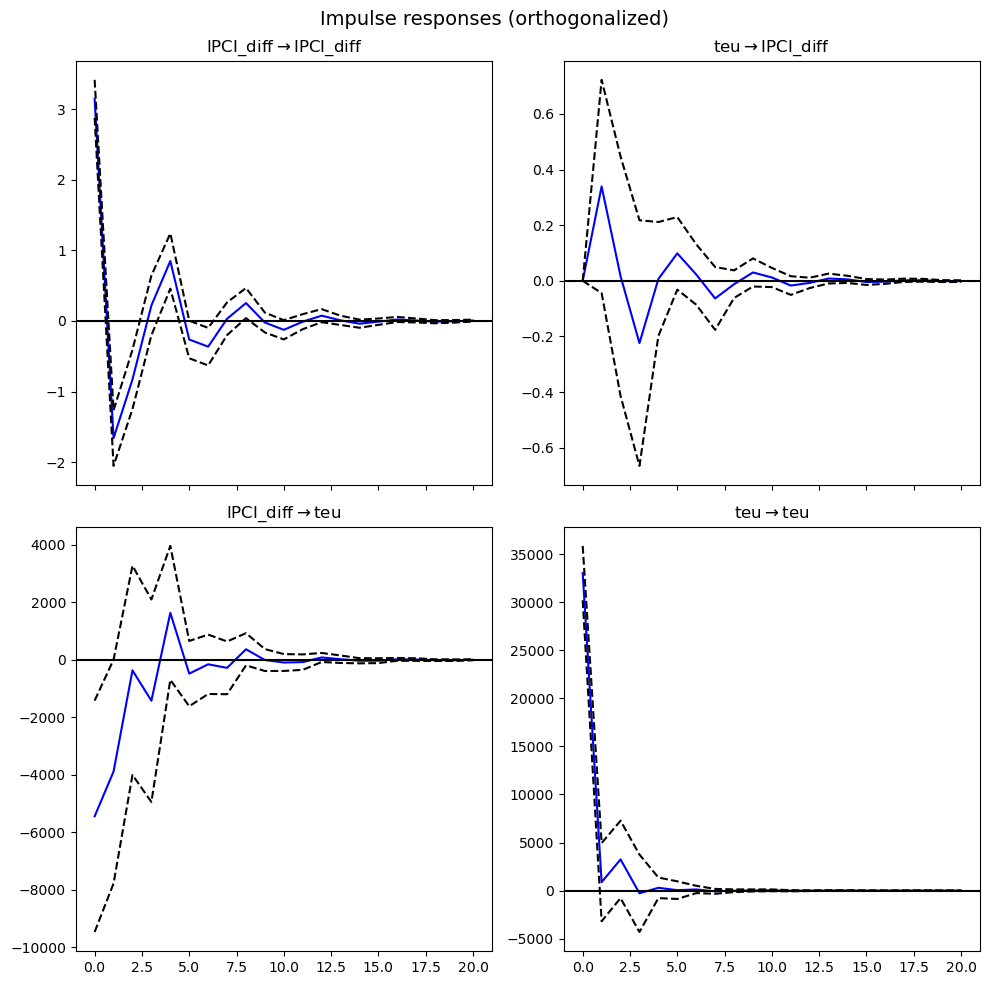

In [105]:
#Impulse Response Analysis
irf = model_fitted.irf(20)  # 20-period impulse response
irf.plot(orth=True)
plt.tight_layout()
plt.show()

In [106]:
#残差自相关检验
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model_fitted.resid

for col in residuals.columns:
    print(f"\n残差自相关检验：{col}")
    lb_test = acorr_ljungbox(residuals[col], lags=[10], return_df=True)
    print(lb_test)


残差自相关检验：IPCI_diff
      lb_stat  lb_pvalue
10  16.558358   0.084726

残差自相关检验：teu
      lb_stat  lb_pvalue
10  21.645098   0.017018


结果表明，对于IPCI_diff，残差**不**存在自相关性；对于teu，残差存在自相关性

In [107]:
#Forecast
forecast = model_fitted.forecast(model_data.values[-optimal_lag:], steps=100)
forecast_start_date = pd.to_datetime('2025-02-03')
forecast_df = pd.DataFrame(forecast, index=pd.date_range(start=model_data.index[-1] + pd.Timedelta(days=1), periods=100, freq='W-MON'), columns=model_data.columns)
forecast_df.to_csv("forecast_df.csv")
print(forecast_df)

            IPCI_diff            teu
2025-02-03  -0.279367  285853.041830
2025-02-10   0.672602  283137.706349
2025-02-17   0.621688  287080.542161
2025-02-24  -0.576044  284309.857161
2025-03-03  -0.253436  285271.041968
...               ...            ...
2026-11-30  -0.005398  285359.009338
2026-12-07  -0.005398  285359.009338
2026-12-14  -0.005398  285359.009338
2026-12-21  -0.005398  285359.009338
2026-12-28  -0.005398  285359.009338

[100 rows x 2 columns]


In [108]:
#IPCI_diff=>IPCI
last_ipci_value = combined_df['IPCI'].iloc[-1]  #The last IPCI value
forecast_df['IPCI'] = last_ipci_value + forecast_df['IPCI_diff'].cumsum()
forecast_df_new=forecast_df[['IPCI', 'teu']]
forecast_df_new.to_csv("forecast_df_new.csv")
print(forecast_df_new)

                IPCI            teu
2025-02-03  0.822187  285853.041830
2025-02-10  1.494789  283137.706349
2025-02-17  2.116477  287080.542161
2025-02-24  1.540433  284309.857161
2025-03-03  1.286997  285271.041968
...              ...            ...
2026-11-30  1.051083  285359.009338
2026-12-07  1.045685  285359.009338
2026-12-14  1.040286  285359.009338
2026-12-21  1.034888  285359.009338
2026-12-28  1.029490  285359.009338

[100 rows x 2 columns]
